<a id="choose-parameters-and-check-the-result"></a>

# Choose parameters and check the result

[Tutorials and examples](../README.md) · Previous: [From two point clouds to a differentiable loss](../getting_started/first_steps.ipynb)

Before tuning a solver, decide what you will do with its output. A training loss, a transport map, and a
curvature estimate place different demands on the solve. This guide connects those choices to the public
`SamplesLoss` arguments and to checks you can perform on your own data.

Source: [guide.md](guide.md) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

This is a reading guide. Follow its example links for runnable notebooks.

<a id="fix-the-mathematical-problem-first"></a>

## Fix the mathematical problem first

Write down the coordinates and their units, the point weights, the pair cost, and the regularization. Changing
any of these changes the problem you are solving.

| Choice | Meaning | Start here |
|---|---|---|
| Point weights | How much mass each point represents | Uniform probability weights, or explicitly normalized weights |
| `half_cost` | `True` uses half the squared distance; `False` uses the full squared distance | Keep it explicit when comparing libraries |
| `debias` | Subtract the two self costs; this gives the balanced Sinkhorn divergence | Start with balanced `debias=True` for a distribution-matching loss; use raw OT when inspecting the cross plan |
| `blur` | Smoothing length, with `eps = blur**2` | Compare it with distances and feature scales in your data |
| `reach_x`, `reach_y` | Strengths of marginal relaxation, with `rho = reach**2` | Leave them `None` while learning balanced transport |

The default `normalize=True` normalizes each side independently. It therefore discards a difference in total
input mass. If you disable normalization, dense costs and weight gradients currently require each side to
already be a probability distribution. With both marginals relaxed, the total transported mass can shrink
even when the input weights are probabilities; this is different from accepting arbitrary input totals.

**Reference figure from previous script runs.**

<a id="interpret-blur-through-a-picture"></a>

## Interpret blur through a picture

A small blur favors concentrated transport and resolves finer structure. A larger blur spreads the coupling
over more possible destinations. This changes the objective itself. Reducing the blur is not merely asking
the same optimization problem for a more accurate answer.

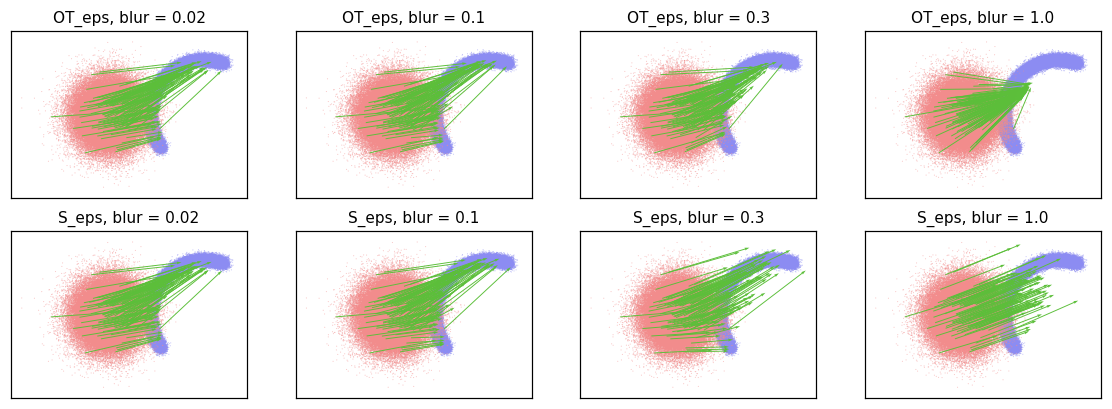

The salmon points are the source and the purple points are the target; green arrows show displacement
directions from the source. Read each column at one blur. The top row shows the raw entropic objective's directions; the bottom row
subtracts the self interaction. Follow one source location across columns: its direction reflects an average
over more target points as the coupling broadens. The debiased directions also remove the cloud's tendency
to move toward its own smoothed interior. Run [Choosing the blur at scale](../getting_started/plot_blur.ipynb)
to regenerate the fields and print the translated-cloud check.

Coordinate units matter. If all coordinates are multiplied by a positive factor `s`, multiplying `blur`
and any finite `reach` by `s` preserves their relative scales for squared cost. The objective then scales
by `s**2`. Rescaling different feature dimensions separately changes their relative influence; choose that
scaling from the meaning of your features, not from solver timing.

<a id="choose-whether-mass-must-match"></a>

## Choose whether mass must match

Balanced transport must account for every source and target mass. An outlier still has to receive or send
its assigned mass. If one cloud contains unmatched material, relaxing a marginal may be the intended model.

| Assumption about the data | Setting |
|---|---|
| Both distributions must be matched fully | `reach_x=None, reach_y=None` |
| Some source mass may be left unmatched; the target is trusted | Finite `reach_x`, `reach_y=None` |
| The source is trusted; some target mass may be left unmatched | `reach_x=None`, finite `reach_y` |
| Both sides may have unmatched material | Finite reaches on both sides |

A smaller finite reach makes deviations from that marginal less expensive. With one strict probability
marginal, the total transported mass is still one: decreasing the mass associated with some points on the
relaxed side must be compensated elsewhere on that side. KL relaxation permits both decreases and increases;
it is not a per-point cap. Inspect the transported masses and where they change; a lower objective alone does
not establish that the chosen relaxation is useful.
The [outliers and missing-mass example](plot_unbalanced.ipynb) shows the two directions of this choice.

When `reach_x != reach_y`, subtracting self costs with `debias=True` does not in general produce a divergence:
the result need not be symmetric, nonnegative, or minimized when the clouds coincide. Keep the balanced
divergence intuition separate from that asymmetric objective.

For relaxed marginals, the balanced residual `P @ 1 - a` is not expected to vanish. At an optimum, a relaxed
source satisfies `P @ 1 = a * exp(-f / rho_x)` and a relaxed target satisfies the corresponding relation with
`b`, `g`, and `rho_y`. Use the optimality condition of the problem you selected.

**Reference figure from previous script runs.**

<a id="distinguish-solving-longer-from-changing-precision"></a>

## Distinguish solving longer from changing precision

The symmetric backend anneals epsilon when `use_epsilon_scaling=True`. Increasing `scaling` toward one
inserts more intermediate epsilon values. This often helps at small blur, but it is not a convergence
certificate. A custom `eps_list` can explicitly add iterations at the target epsilon. With a fixed epsilon,
use `use_epsilon_scaling=False`, `eps`, and `n_iters`.

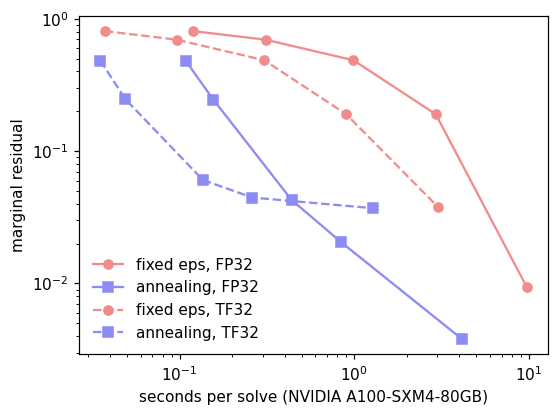

Read downward for a more accurate reconstructed plan and leftward for a faster solve. A curve flattening
with extra work suggests that iteration count is no longer the only limiting factor. The plotted residual
uses FP32 reconstruction on the original points; the coordinate distinction in the next section matters
when interpreting the TF32 curves. The [convergence example](plot_convergence.ipynb) prints every plotted result.

`threshold` in the dense backends checks changes in potentials at the target epsilon. It does not certify
a marginal-residual bound. A warning that a check was not confirmed means the requested test did not pass;
it should influence how you use the result. The multiscale backend has a different, sampled marginal check
controlled by `tol`, and returns its status in `last_multiscale_info`.

<a id="precision-and-the-coordinates-being-solved"></a>

### Precision and the coordinates being solved

By default, dense `SamplesLoss` centres FP32/FP64 input coordinates and rounds them to TF32 before evaluating
norms and TF32 dot products. `truncate_tf32=None` follows `allow_tf32`. The rounding has an identity autograd
derivative; FP32 arithmetic error still remains. fp16/bf16 inputs receive no additional rounding.

For an FP32 comparison on unrounded centred coordinates, use `allow_tf32=False`. For a controlled comparison,
hold the inputs, weights, cost convention, epsilon schedule and objective fixed. `truncate_tf32=False` with
TF32 still enabled restores unrounded centred coordinates, but the dot products still use TF32; that setting
does not provide full FP32 arithmetic.

A transport plan reconstructed on the original coordinates can have a residual even if the solve on rounded
coordinates has converged. More iterations cannot remove the coordinate displacement. This is especially
relevant for high-dimensional features and small epsilon; the [embeddings example](../scale/plot_embeddings.ipynb)
shows how to inspect the effect on your intended reconstruction.

<a id="decide-which-backend-matches-the-task"></a>

## Decide which backend matches the task

| Task | Backend and considerations |
|---|---|
| General squared-Euclidean loss or first derivatives | Start with `symmetric`; tune its schedule after establishing a reference |
| Fixed-epsilon alternating updates | `alternating`, with `use_epsilon_scaling=False`, `eps`, and `n_iters` |
| Large balanced 3-D clouds, forward cost or potentials | `multiscale`; inspect its acceptance status and documented limits |
| Batches, high-dimensional features, relaxed marginals, or coordinate gradients | Use a dense backend; multiscale does not support these cases |

The two dense backends target the same mathematical problem when their conventions match. Their finite
iteration sequences differ. Compare plans or remove the free additive constant before comparing balanced
potentials. The [library-conventions example](plot_conventions.ipynb) explains the cost, regularization and
potential conversions used for GeomLoss and OTT-JAX comparisons.

<a id="a-checklist-before-using-the-result"></a>

## A checklist before using the result

1. **Name the output.** Are you using a scalar divergence, raw cost, potentials, a plan application, or an HVP?
2. **Check the problem.** Confirm weights, coordinate units, half/full cost, epsilon, and any relaxed side.
3. **Check stability.** Compare with a more careful solve and read every convergence warning.
4. **Check the quantity you need.** For a balanced plan, inspect both marginals; for a relaxed plan, use its
   relaxed optimality conditions; for an optimization loop, inspect both the objective and the resulting geometry.
5. **Check the precision.** Establish an FP32 comparison on the same problem before interpreting TF32 differences.
6. **Then measure speed.** Separate the first call from repeated calls, synchronize CUDA for timing, and report
   the actual device and memory use.

For second derivatives, the supported `SamplesLoss` HVP is x-only with `debias=False`, no y gradient, and no
label cost. It uses an iterative linear solve whose convergence warnings matter. `SamplesLoss(autotune=False)`
controls forward and first-derivative kernels; its HVP path currently has its own default tuning behavior.
The [curvature tutorial](../advanced/plot_hvp_newton.ipynb) demonstrates a small parameter model with these limits
made explicit.

Return to the [case gallery](../README.md#situations) for particle flows, attribute transfer, labelled datasets,
high-dimensional embeddings, batches, and large 3-D clouds. The [API reference](../../API.md) lists the complete
parameter contracts; the [GeomLoss gallery](https://www.kernel-operations.io/geomloss/_auto_examples/index.html)
and [OTT-JAX tutorials](https://ott-jax.readthedocs.io/tutorials/index.html) provide further OT applications.